In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from run_evolution import folder_evol
from analytical_results import fT00, fT01, fT11, fj0, fj1, fnu, fLn

from sklearn.decomposition import PCA
from scipy.special import jv, gammaincc, gamma
from scipy.optimize import minimize

save = False

In [2]:
g = 1
v = 1
Q = 1
dt = 1 / 16
tol = 1e-6
method = '12site'
mlat = True

data = {}
ms = [0.0, 0.1, 0.2, 0.3183, 0.4, 0.5, 0.6, 0.7, 0.8]
for m in ms:
    for (N, a) in [(512, 1/8), (1024, 1 / 16)]:
        for D in [128, 256]:
            folder = folder_evol(g, m, a, N, v, Q, D, dt, D, tol, method, mlat, mkdir=False)
            try:
                d = np.load(folder / f"results.npy", allow_pickle=True).item()
                data[m, N, a, D] = d
            except FileNotFoundError:
                pass

# labels for projections on 1 and 2 bonds
E1s = np.array([-3, -2, -1, 0, 1, 2, 3]) - 1  # -1 to take into account left-moving charge
E2s = np.array([-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]) / 2 - 1  # -1 to take into account left-moving charge

#  initial time for fitting
t0 = 2.0
#
# parameters for fit
N, a, D = 512, 0.125, 256


In [3]:
# calculated quantities
for x in sorted(data[0.5, 512, 1/8, 128].keys()):
    print(x)

Ln
T00
T01
T11
energy
ent1a
ent1b
ent1c
ent2a
ent2b
entropy_1
entropy_2
entropy_3
evol_time
j0
j1
min_Schmidt
nu
pr11
pr1a
pr1b
pr1c
pr2
time


In [4]:
plt.rcParams.update({'font.size':16})
plt.rcParams.update({'legend.fontsize':12})
plt.rcParams['figure.constrained_layout.use'] = True


m=0.50, eps_string=0.952194, bLkappa2=0.028373 tt=0.00000  Optimization terminated successfully.
m=0.60, eps_string=0.914392, bLkappa2=0.014548 tt=0.00000  Optimization terminated successfully.
m=0.70, eps_string=0.896503, bLkappa2=0.006603 tt=0.00000  Optimization terminated successfully.


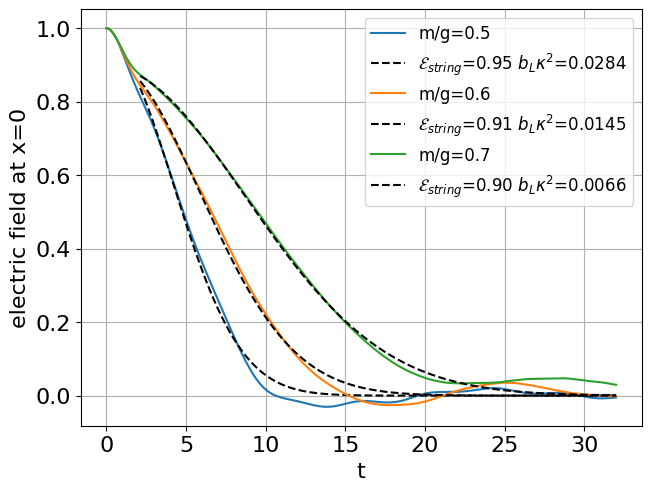

: 

In [ ]:
# Fig 2a

mfits = []
bkappa2_Ln = []

for m in [0.5, 0.6, 0.7]:
    d = data[m, N, a, D]
    time = d['time']
    Ln = ((d['pr1b'] + d['pr1c']) / 2) @ E1s
    plt.plot(time, -Ln, label=f"{m/g=:0.1f}")

    slc = time > t0
    x = time[slc]
    y = Ln[slc]

    def f(b, al, tau):
        return gammaincc(1+al, b*tau**2)

    def mse(pars):
        eps_string, bLkappa2 = pars
        tt = 0
        return np.mean((y + eps_string * f(bLkappa2, 0, x - tt)) ** 2)

    x0 = (0.9, np.exp(-2.2 - 6 * m * m))
    sol = minimize(mse, x0)

    eps_string, bLkappa2 = sol.x
    tt = 0

    mfits.append(m)
    bkappa2_Ln.append(bLkappa2)

    print(f"{m=:0.2f}, {eps_string=:0.6f}, {bLkappa2=:0.6f} {tt=:0.5f}  {sol.message}")

    plt.plot(x, eps_string * f(bLkappa2, 0, x- tt), '--k', label=r"${\cal E}_{string}$" + f"={eps_string:0.2f} " + r"$b_L\kappa^2$" + f"={bLkappa2:0.4f}")

plt.xlabel('t')
plt.ylabel('electric field at x=0')
plt.grid()
plt.legend()

plt.savefig('Fig2a.png')

In [ ]:
# m=0.50, eps_string=0.952194, bLkappa2=0.028373 tt=0.00000  Optimization terminated successfully.
# m=0.60, eps_string=0.914392, bLkappa2=0.014548 tt=0.00000  Optimization terminated successfully.
# m=0.70, eps_string=0.896503, bLkappa2=0.006603 tt=0.00000  Optimization terminated successfully.

In [ ]:
# m=0.50, eps_string=0.801580, bLkappa2=0.040239 tt=1.49518  Optimization terminated successfully.
# m=0.60, eps_string=0.827313, bLkappa2=0.018444 tt=1.37468  Optimization terminated successfully.
# m=0.70, eps_string=0.888767, bLkappa2=0.006755 tt=0.19560  Optimization terminated successfully.

2.043625706800385 6.074453368519634


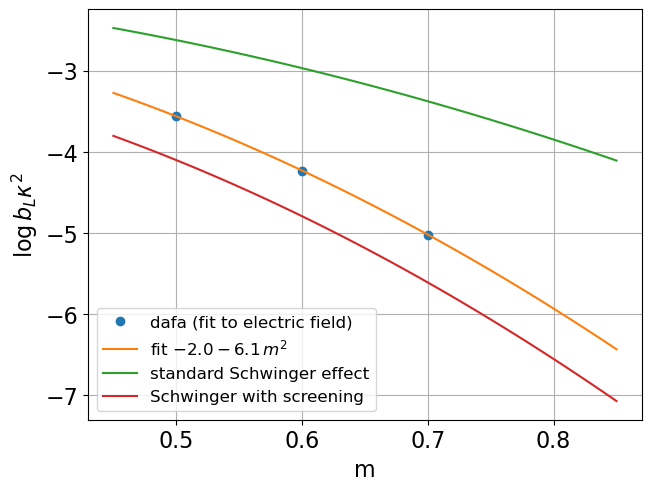

In [18]:
# Fig 2b
N, a, D = 1024, 0.0625, 256

mfits = np.array(mfits)
bkappa2_Ln = np.array(bkappa2_Ln)
plt.plot(mfits, np.log(bkappa2_Ln), 'o', label='dafa (fit to electric field)')

def mse(pars):
    kk, ll = pars
    return np.mean((np.log(bkappa2_Ln) + kk + ll * mfits ** 2) ** 2)

x0 = (2, 6)
sol = minimize(mse, x0)
kk, ll = sol.x
mrange = np.linspace(0.45, 0.85, 101)
plt.plot(mrange , - kk - ll * mrange ** 2, label=r'fit $-2.0 - 6.1\, m^2$')

print(kk, ll)

plt.plot(mrange , np.log(1/(2 * np.pi)) - np.pi * mrange ** 2, label='standard Schwinger effect')

plt.plot(mrange , np.log(1/(4 * np.pi)) - 2 * np.pi * mrange ** 2, label='Schwinger with screening')


plt.xlabel("m")
plt.ylabel(r"$\log b_L \kappa^2$")
plt.legend()
plt.grid()

plt.savefig('Fig2b.png')

m=0.50, eps_string=0.767638, bLkappa2=0.026101 const=0.08870  Desired error not necessarily achieved due to precision loss.
m=0.60, eps_string=0.754391, bLkappa2=0.013531 const=0.14279  Desired error not necessarily achieved due to precision loss.
m=0.70, eps_string=0.748844, bLkappa2=0.006578 const=0.22305  Desired error not necessarily achieved due to precision loss.


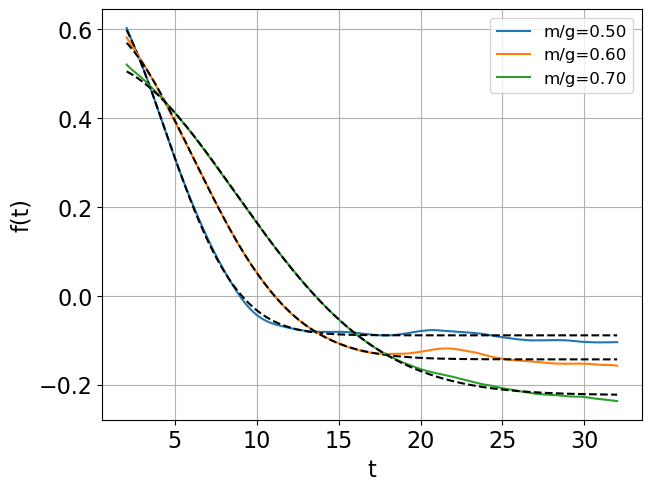

In [21]:
# Fig 2c

mfits = []
bkappa2_prob = []
sols = []
pcas = []
means = []

for m in [0.5, 0.6, 0.7]:
    d = data[m, N, a, D]
    time = d['time']

    slc = time > t0
    x = time[slc]

    prob_mid = (d['pr1b'] + d['pr1c']) / 2
    prob_mid = prob_mid[slc]
    pcaproj = PCA(n_components=1)
    pcaproj.fit(prob_mid)
    y = pcaproj.transform(prob_mid).ravel()

    plt.plot(x, y, label=f"{m/g=:0.2f}")

    def f(b, al, tau):
        return gammaincc(1 + al, b * tau ** 2)

    def mse_prob(pars):
        eps_string, bLkappa2, const = pars
        return np.mean(np.abs((y + const - eps_string * f(bLkappa2, 0, x))))

    x0 = (0.75, np.exp(-2.2 - 6 * m * m),  0.64 * m - 0.23)
    sol = minimize(mse_prob, x0)
    eps_string, bLkappa2, const = sol.x
    print(f"{m=:0.2f}, {eps_string=:0.6f}, {bLkappa2=:0.6f} {const=:0.5f}  {sol.message}")
    plt.plot(x, eps_string * f(bLkappa2, 0, x) - const, '--k')

    sols.append(sol)
    pcas.append(pcaproj)
    means.append(np.mean(prob_mid, axis=0))

    mfits.append(m)
    bkappa2_prob.append(bLkappa2)

plt.legend()
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid()

plt.savefig('Fig2c.png')

[0.0, 0.1, 0.2, 0.3183, 0.4, 0.5, 0.6, 0.7, 0.8] [np.float64(0.8391750917521335), np.float64(0.8877841940661299), np.float64(0.9437685460563363), np.float64(0.9770039735334731), np.float64(0.9884183064412942), np.float64(0.99384525451494), np.float64(0.995697344621313), np.float64(0.9980122047609378)]


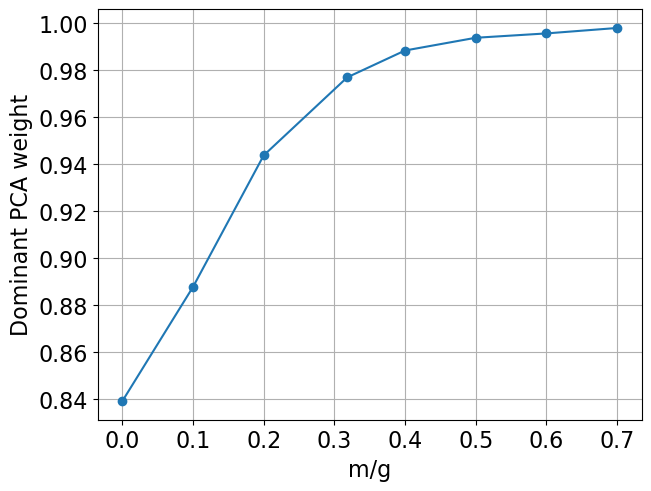

In [26]:
# Fig 3a

pca = PCA()

dom = []
for m in ms[:-1]:
    d = data[m, N, a, D]
    time = d['time']
    probs = ((d['pr1b'] + d['pr1c']) / 2)

    slc = time > 0
    x = time[slc]
    probs = probs[slc]

    pca.fit(probs)
    y = pca.explained_variance_ratio_[0]
    dom.append(y)
plt.plot(ms[:-1], dom, '-o',label=f"1-bond proj")

print(ms, dom)
plt.xlabel("m/g")
plt.ylabel("Dominant PCA weight")
#plt.legend()
plt.grid()

plt.savefig('Fig3a.png')

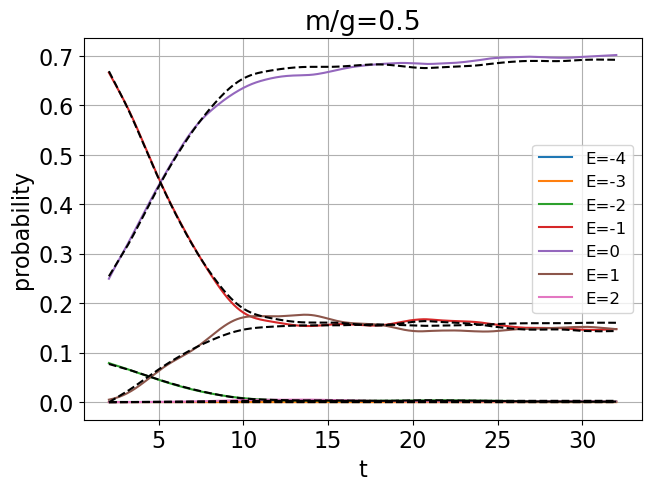

In [61]:
# Fig 3b

pca = PCA(n_components=1)

dom = []
m = 0.5

d = data[m, N, a, D]
time = d['time']
probsall = ((d['pr1b'] + d['pr1c']) / 2)

slc = time > t0
x = time[slc]
probs = probsall[slc]

pca.fit(probs)
y = pca.transform(probs)
cc = pca.components_

for ii, EE in enumerate(E1s):
    plt.plot(x, probs[:, ii], label=f"E={EE:1d}")
    #plt.plot(time, probsall[:, ii], label=f"E={EE:1d}")

reconstruct = y @ cc + np.mean(probs, axis=0)
plt.plot(x, reconstruct, '--k')


plt.xlabel("t")
plt.ylabel("probability")

plt.title(f"{m/g=:0.1f}") #
plt.legend()
plt.grid()

plt.savefig('Fig3b.png')

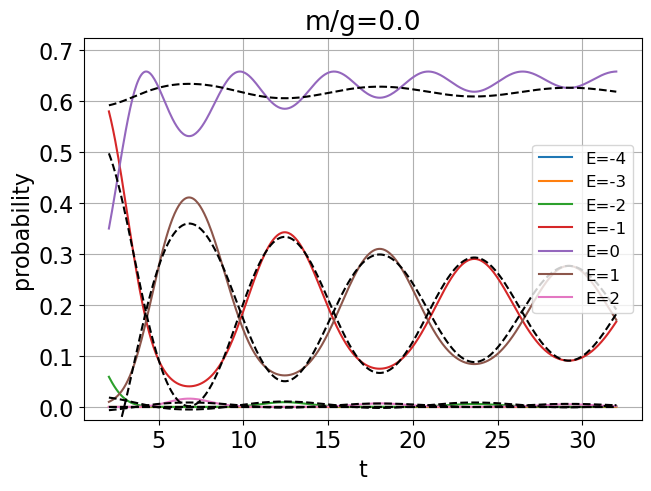

In [60]:
# Fig 3c

pca = PCA(n_components=1)

dom = []
m = 0.0

d = data[m, N, a, D]
time = d['time']
probs = ((d['pr1b'] + d['pr1c']) / 2)

slc = time > t0
x = time[slc]
probs = probs[slc]

pca.fit(probs)
y = pca.transform(probs)
cc = pca.components_

for ii, EE in enumerate(E1s):
    plt.plot(x, probs[:, ii], label=f"E={EE:1d}")

reconstruct = y @ cc + np.mean(probs, axis=0)
plt.plot(x, reconstruct, '--k')


plt.xlabel("t")
plt.ylabel("probability")
plt.title(f"{m/g=:0.1f}") #  two PCA components needed")
plt.ylim([-0.025, 0.725])
plt.legend()

plt.grid()

plt.savefig('Fig3c.png')

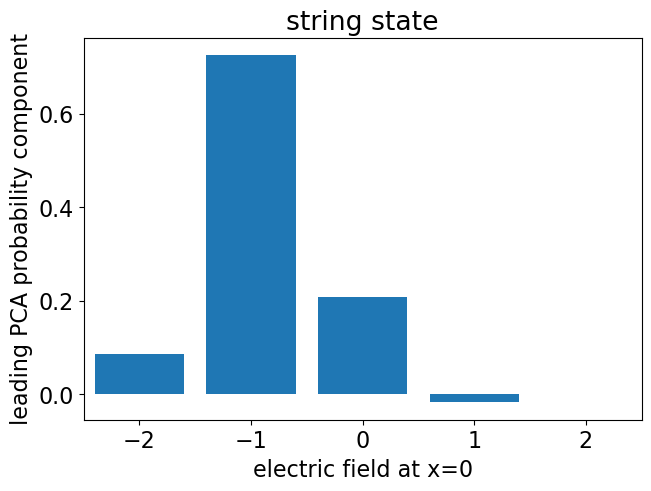

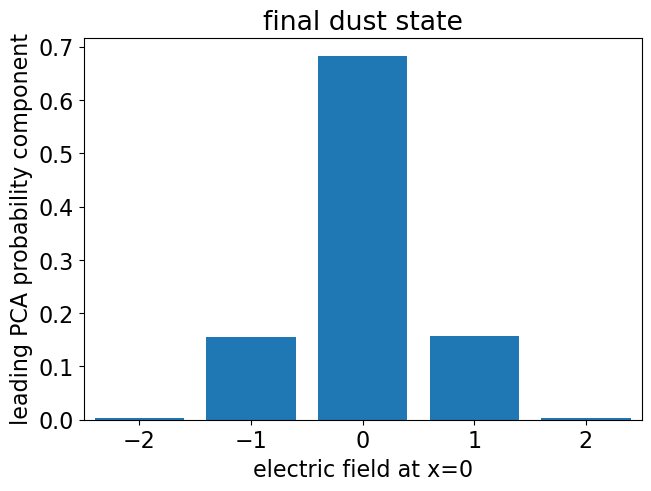

In [38]:
# Fig 4a 4b

iii = 0  # m = 0.5

m = 0.5
d = data[m, N, a, D]
time = d['time']
prob_mid = (d['pr1b'] + d['pr1c']) / 2
ind = np.argmin(abs(time - 0))

cc, _, aa = sols[iii].x  # m = 0.5

p1 = pcas[iii].components_.reshape(-1)
p0 = means[iii].reshape(-1)

pstring = p0 + (cc - aa) * p1
pdust = p0 + (0 - aa) * p1;

plt.bar(E1s, pstring)
plt.xlabel('electric field at x=0')
plt.ylabel('leading PCA probability component')
plt.title('string state')
plt.xlim([-2.5, 2.5]);

plt.savefig('Fig4a.png')

plt.figure()
plt.bar(E1s, pdust)
plt.xlabel('electric field at x=0')
plt.ylabel('leading PCA probability component')
plt.title('final dust state')
plt.xlim([-2.5, 2.5]);


plt.savefig('Fig4b.png')

/tmp/ipykernel_1193925/467477792.py:37: RuntimeWarning: divide by zero encountered in divide
  T00model = np.sqrt(np.pi/b)/(4*ts) *erf(np.sqrt(b)*ts)
/tmp/ipykernel_1193925/467477792.py:37: RuntimeWarning: invalid value encountered in multiply
  T00model = np.sqrt(np.pi/b)/(4*ts) *erf(np.sqrt(b)*ts)
/tmp/ipykernel_1193925/467477792.py:39: RuntimeWarning: divide by zero encountered in power
  T00modelbis = 0.5*np.exp(-b*ts**2) + 0.5*(b*ts**2)**(-(1+w)/2) * gamma((3+w)/2) * (1 - gammaincc((3+w)/2, b*ts**2))
/tmp/ipykernel_1193925/467477792.py:39: RuntimeWarning: invalid value encountered in multiply
  T00modelbis = 0.5*np.exp(-b*ts**2) + 0.5*(b*ts**2)**(-(1+w)/2) * gamma((3+w)/2) * (1 - gammaincc((3+w)/2, b*ts**2))
/tmp/ipykernel_1193925/467477792.py:40: RuntimeWarning: divide by zero encountered in power
  T11modelbis = -0.5*np.exp(-b*ts**2) + 0.5*w*(b*ts**2)**(-(1+w)/2) * gamma((3+w)/2) * (1 - gammaincc((3+w)/2, b*ts**2))
/tmp/ipykernel_1193925/467477792.py:40: RuntimeWarning: invalid 

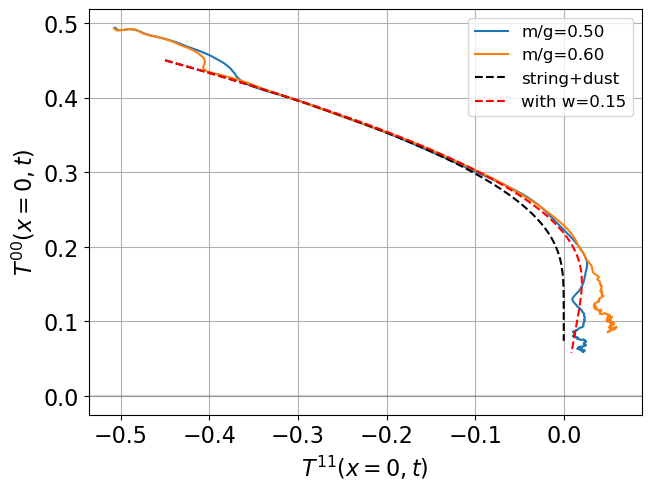

In [ ]:
# Fig 4c

from scipy.special import jv, gammaincc, gamma, erf

def get_tsm(signals, ev):
    tm = signals["time"]
    mask = tm > -1
    tm = tm[mask]
    ee = signals[ev][mask]
    ee = ee - ee[0, :]
    ee = (ee[:, 0::2] + ee[:, 1::2]) / 2  # average over 2*n and 2*n+1
    mid = (ee[:, N//4] +ee[:, N//4-1])/2
    return tm, ee, mid


plt.figure()

sl = slice(3, -1)

for i, m in enumerate([0.5, 0.6]):

    d = data[m, N, a, D]

    tm, _, T00 = get_tsm(d, 'T00')
    _ , _, T11 = get_tsm(d, 'T11')


    plt.plot(T11[sl], T00[sl], label=f'{m/g=:0.2f}')


w = 0.15 # w=0.2 seems here better
b = 0.0284

ts = d['time']

T11model = -0.5*np.exp(-b*ts**2)
T00model = np.sqrt(np.pi/b)/(4*ts) *erf(np.sqrt(b)*ts)

T00modelbis = 0.5*np.exp(-b*ts**2) + 0.5*(b*ts**2)**(-(1+w)/2) * gamma((3+w)/2) * (1 - gammaincc((3+w)/2, b*ts**2))
T11modelbis = -0.5*np.exp(-b*ts**2) + 0.5*w*(b*ts**2)**(-(1+w)/2) * gamma((3+w)/2) * (1 - gammaincc((3+w)/2, b*ts**2))

T00model = np.sqrt(np.pi/b)/(4*ts) *erf(np.sqrt(b)*ts)

# test for w=0
# print(np.linalg.norm(T00model - T00modelbis))
# quit()

# test ok
# bb = 0.023
# ttt = 5.312
# print((bb*ttt**2)**(-(1+w)/2) * gamma((3+w)/2) * (1 - gammaincc((3+w)/2, bb*ttt**2)))

plt.plot(0.9*T11model, 0.9*T00model, color='k', linestyle='dashed', label='string+dust')
plt.plot(0.9*T11modelbis, 0.9*T00modelbis, color='r', linestyle='dashed', label='with w={}'.format(w))

# plt.plot(0.928*T11model, 0.928*T00model, color='k', linestyle='dashed', label='string+dust')
# plt.plot(0.928*T11modelbis, 0.928*T00modelbis, color='r', linestyle='dashed', label='with w={}'.format(w))


plt.axhline(0, color='k', alpha=0.15)

plt.legend(loc='upper right')
plt.xlabel(r'$T^{11}(x=0, t)$')
plt.ylabel(r'$T^{00}(x=0, t)$')
plt.grid()


plt.savefig('Fig4c.png')

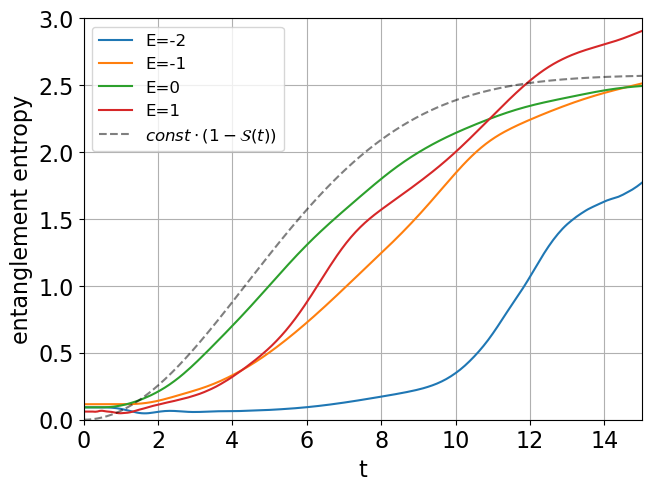

In [40]:
# Fig 5

Sinf = (d['ent1b'][-1, 4]+d['ent1c'][-1, 4])/2
S0 = (d['ent1b'][0, 4]+d['ent1c'][0, 4])/2
t = d['time']
reference = (1 - np.exp(-0.026101*t**2))
#plt.plot(t, d['ent2b'][:, 8], label='ent2b')
plt.plot(t, (d['ent1b'][:, 2]+d['ent1c'][:, 2])/2, label='E=-2')
plt.plot(t, (d['ent1b'][:, 3]+d['ent1c'][:, 3])/2, label='E=-1')
plt.plot(t, (d['ent1b'][:, 4]+d['ent1c'][:, 4])/2, label='E=0')
plt.plot(t, (d['ent1b'][:, 5]+d['ent1c'][:, 5])/2, label='E=1')
plt.plot(t, Sinf*reference, color='k', linestyle='dashed', alpha=0.5, label=r'$const \cdot (1-{\cal S}(t))$')
#plt.plot(t2, S0 + (Sinf-S0)*(1-np.exp(-0.02*(t2-0.3)**2)), label='S0 +(Sinf-S0) (1-exp(-0.02(t-0.3)^2)')
plt.grid()
plt.legend()
plt.xlabel('t')
plt.ylabel('entanglement entropy')
plt.xlim(0,15)
plt.ylim(0,3.0)
plt.savefig('Fig5.png')

In [62]:
print(E1s @ pstring)
print((E1s * E1s) @ pstring / 2)


-0.9159102362228599
0.5237174525233923


In [29]:
pstring

array([-1.95346298e-08,  1.20315160e-04,  8.90245405e-02,  7.24032020e-01,
        2.01010386e-01, -1.36824063e-02, -5.04591026e-04])

In [30]:
pstringpos = pstring.copy()
pstringpos[pstringpos<0]=0
pstringpos

array([0.00000000e+00, 1.20315160e-04, 8.90245405e-02, 7.24032020e-01,
       2.01010386e-01, 0.00000000e+00, 0.00000000e+00])

In [31]:
pstringpos = pstringpos/np.sum(pstringpos)

In [32]:
pstringpos

array([0.00000000e+00, 1.18632095e-04, 8.77791941e-02, 7.13903681e-01,
       1.98198493e-01, 0.00000000e+00, 0.00000000e+00])

In [33]:
print(E1s @ pstringpos)
print((E1s * E1s) @ pstringpos / 2)

-0.8898179657861298
0.5330440733071052
